# Project 2 - Exploratory Data Analysis

Dataset: Dataset_for_Data_Analytics.xlsx (1200 e-commerce order records)

Goal of this project is to explore the dataset - check data quality, look at
distributions, find outliers, and see how the columns relate to each other.
Nothing predictive here, just understanding the data first.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## 2. Load the data

In [2]:
df = pd.read_csv("../data/raw/orders_raw.csv", parse_dates=["Date"])
print(df.shape)
df.head()

(1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


## 3. Missing values and duplicates

Checking for missing data, duplicate rows, and whether the numbers actually
add up (Quantity x UnitPrice should equal TotalPrice).

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
quality_report[quality_report["Missing Count"] > 0]

,Missing Count,Missing %
CouponCode,309,25.75


CouponCode has around 26% missing values. That's not really a data problem
though - a blank coupon code just means the customer didn't use one. I'll fill
it with "NONE" later instead of dropping those rows.

In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate OrderIDs:", df['OrderID'].duplicated().sum())

mismatch = (abs(df['Quantity'] * df['UnitPrice'] - df['TotalPrice']) > 0.01).sum()
print("Rows where Quantity x UnitPrice != TotalPrice:", mismatch)

Duplicate rows: 0
Duplicate OrderIDs: 0
Rows where Quantity x UnitPrice != TotalPrice: 0


No duplicates and no mismatches - the data is consistent.

## 4. Cleaning

Filling CouponCode's blanks with "NONE", and adding OrderMonth / OrderYear
columns for the trend chart later.

In [6]:
df_clean = df.copy()
df_clean["CouponCode"] = df_clean["CouponCode"].fillna("NONE")
df_clean["OrderMonth"] = df_clean["Date"].dt.to_period("M").astype(str)
df_clean["OrderYear"] = df_clean["Date"].dt.year

df_clean.to_csv("../data/cleaned/orders_cleaned.csv", index=False)
print(df_clean.shape)
df_clean.head()

(1200, 16)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderMonth,OrderYear
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023-01,2023
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024-08,2024
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024-02,2024
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023-10,2023
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025-05,2025


## 5. Basic stats

In [7]:
num_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
df_clean[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00
UnitPrice,1200.0,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93
ItemsInCart,1200.0,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00
TotalPrice,1200.0,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40


In [8]:
summary = pd.DataFrame({
    "Mean": df_clean[num_cols].mean(),
    "Median": df_clean[num_cols].median(),
    "Std Dev": df_clean[num_cols].std(),
    "Skewness": df_clean[num_cols].skew(),
})
summary.round(2)

,Mean,Median,Std Dev,Skewness
Quantity,2.95,3.00,1.41,0.03
UnitPrice,356.41,364.21,197.18,-0.03
ItemsInCart,5.48,5.00,2.28,0.00
TotalPrice,1053.97,823.62,819.86,0.89


TotalPrice has a skew of about 0.89, so it's right-skewed - median is a
better representative value than mean here. UnitPrice skew is close to 0, so
it's roughly symmetric.

## 6. Distributions

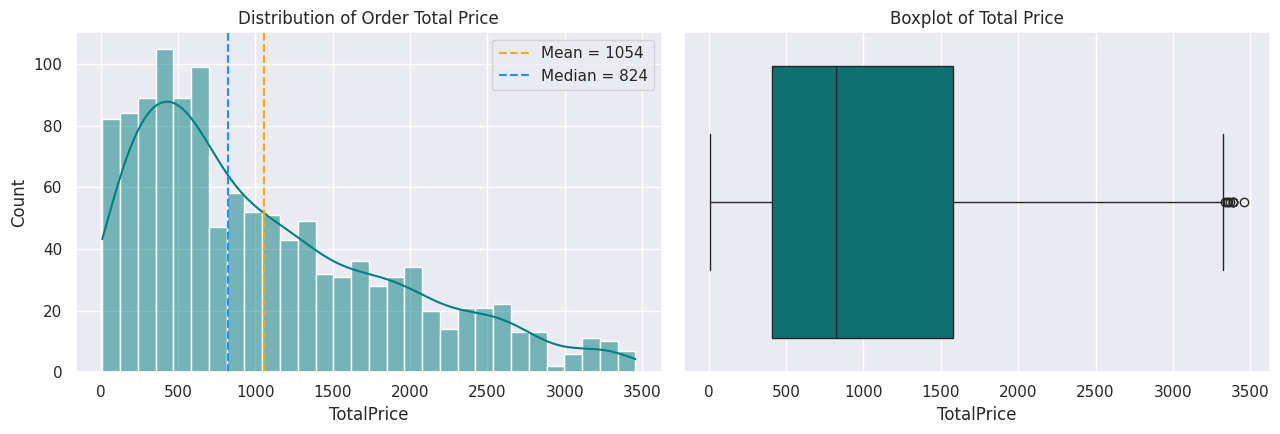

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_clean["TotalPrice"], bins=30, kde=True, color="teal", ax=axes[0])
axes[0].axvline(df_clean["TotalPrice"].mean(), color="orange", ls="--", label=f'Mean = {df_clean["TotalPrice"].mean():.0f}')
axes[0].axvline(df_clean["TotalPrice"].median(), color="dodgerblue", ls="--", label=f'Median = {df_clean["TotalPrice"].median():.0f}')
axes[0].set_title("Distribution of Order Total Price")
axes[0].legend()

sns.boxplot(x=df_clean["TotalPrice"], color="teal", ax=axes[1])
axes[1].set_title("Boxplot of Total Price")
plt.tight_layout()
plt.savefig("../visuals/02_totalprice_distribution.png", dpi=150)
plt.show()

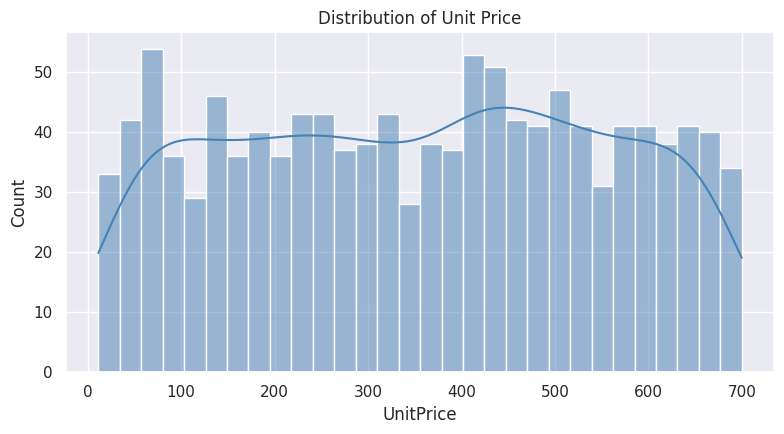

In [10]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df_clean["UnitPrice"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Unit Price")
plt.tight_layout()
plt.savefig("../visuals/03_unitprice_distribution.png", dpi=150)
plt.show()

## 7. Outliers (IQR method)

Flagging anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

In [11]:
outlier_rows = {}
for col in num_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    outlier_rows[col] = mask.sum()
    print(f"{col:12s} -> {mask.sum():3d} outliers  | bounds: [{lower:.2f}, {upper:.2f}]")

outlier_summary = pd.Series(outlier_rows, name="Outlier Count")
outlier_summary

Quantity     ->   0 outliers  | bounds: [-1.00, 7.00]
UnitPrice    ->   0 outliers  | bounds: [-317.20, 1024.83]
ItemsInCart  ->   0 outliers  | bounds: [-0.50, 11.50]
TotalPrice   ->   8 outliers  | bounds: [-1341.41, 3330.41]


Quantity       0
UnitPrice      0
ItemsInCart    0
TotalPrice     8
Name: Outlier Count, dtype: int64

Quantity, UnitPrice and ItemsInCart have no outliers. TotalPrice has 8 -
these are orders with both high quantity and high unit price. Looking at them
below, they seem like genuinely large orders, not data errors, so I'm keeping
them rather than removing.

In [12]:
Q1, Q3 = df_clean["TotalPrice"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
high_value_orders = df_clean[df_clean["TotalPrice"] > upper].sort_values("TotalPrice", ascending=False)
high_value_orders[["OrderID", "Product", "Quantity", "UnitPrice", "TotalPrice", "PaymentMethod"]]

,OrderID,Product,Quantity,UnitPrice,TotalPrice,PaymentMethod
789,ORD200789,Tablet,5,691.28,3456.40,Online
1122,ORD201122,Monitor,5,678.19,3390.95,Online
632,ORD200632,Laptop,5,678.16,3390.80,Gift Card
469,ORD200469,Chair,5,676.98,3384.90,Cash
328,ORD200328,Tablet,5,674.04,3370.20,Online
107,ORD200107,Printer,5,670.75,3353.75,Gift Card
326,ORD200326,Laptop,5,670.48,3352.40,Gift Card
1065,ORD201065,Printer,5,666.80,3334.00,Debit Card


## 8. Categorical breakdown

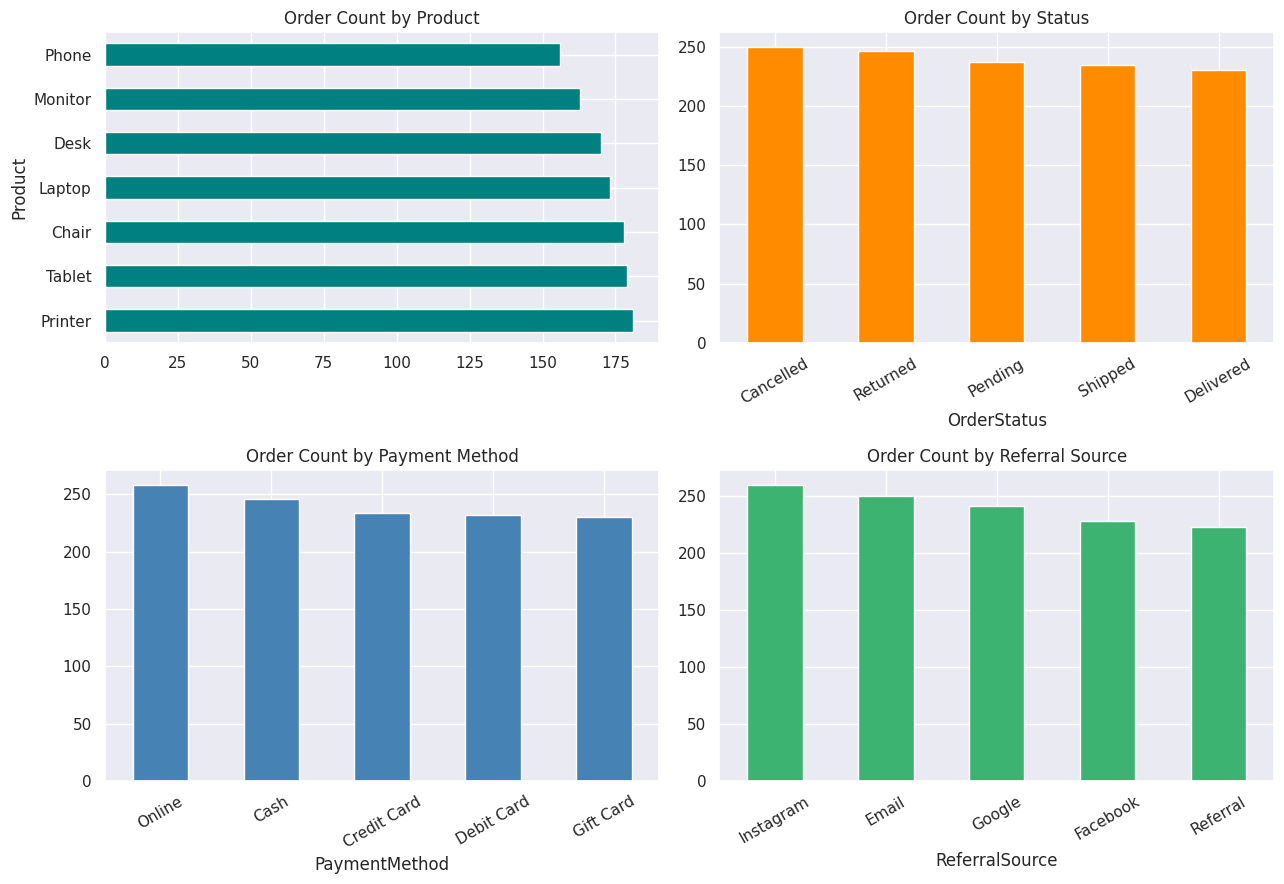

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

df_clean["Product"].value_counts().plot(kind="barh", ax=axes[0,0], color="teal")
axes[0,0].set_title("Order Count by Product")

df_clean["OrderStatus"].value_counts().plot(kind="bar", ax=axes[0,1], color="darkorange")
axes[0,1].set_title("Order Count by Status")
axes[0,1].tick_params(axis='x', rotation=30)

df_clean["PaymentMethod"].value_counts().plot(kind="bar", ax=axes[1,0], color="steelblue")
axes[1,0].set_title("Order Count by Payment Method")
axes[1,0].tick_params(axis='x', rotation=30)

df_clean["ReferralSource"].value_counts().plot(kind="bar", ax=axes[1,1], color="mediumseagreen")
axes[1,1].set_title("Order Count by Referral Source")
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../visuals/05_orders_by_status.png", dpi=150)
plt.show()

## 9. Revenue by category

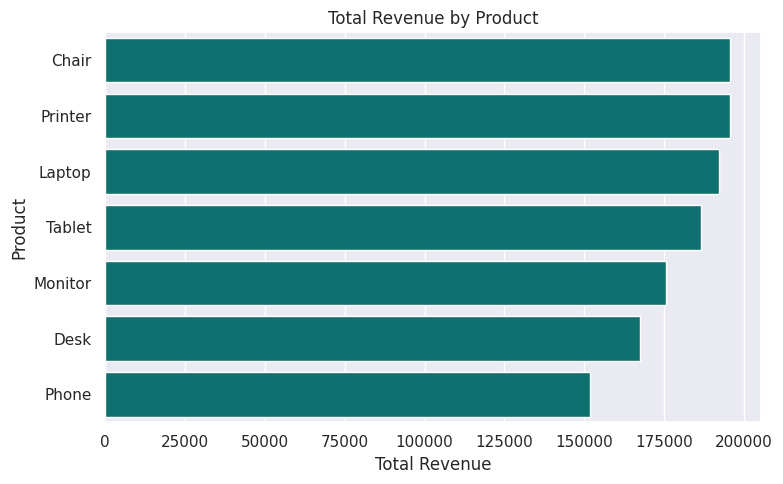

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

In [14]:
rev_by_product = df_clean.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=rev_by_product.values, y=rev_by_product.index, color="teal")
plt.title("Total Revenue by Product")
plt.xlabel("Total Revenue")
plt.tight_layout()
plt.savefig("../visuals/04_revenue_by_product.png", dpi=150)
plt.show()

rev_by_product

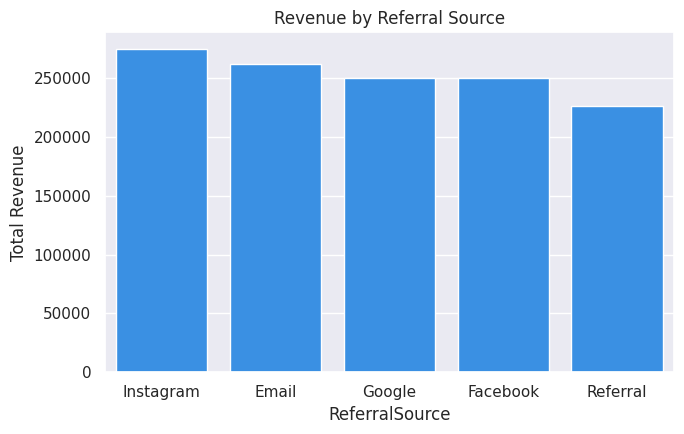

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

In [15]:
ref_rev = df_clean.groupby("ReferralSource")["TotalPrice"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 4.5))
sns.barplot(x=ref_rev.index, y=ref_rev.values, color="dodgerblue")
plt.title("Revenue by Referral Source")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("../visuals/08_revenue_by_referral.png", dpi=150)
plt.show()

ref_rev

## 10. Revenue trend over time

Data covers Jan 2023 to Jun 2025.

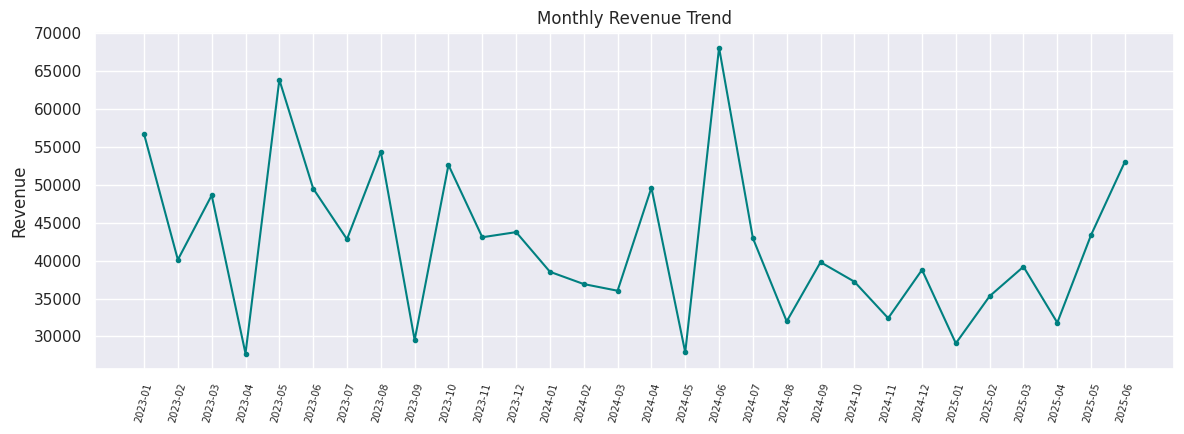

In [16]:
monthly = df_clean.groupby("OrderMonth")["TotalPrice"].sum().sort_index()
plt.figure(figsize=(12, 4.5))
plt.plot(monthly.index, monthly.values, color="teal", marker="o", ms=3)
plt.xticks(rotation=75, fontsize=7)
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("../visuals/07_monthly_revenue_trend.png", dpi=150)
plt.show()

## 11. Correlation

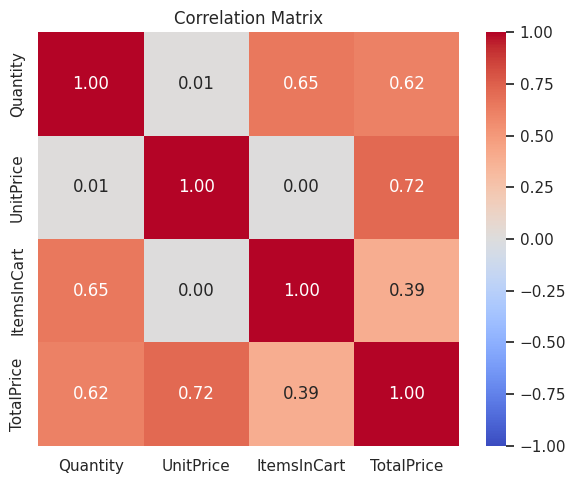

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


In [17]:
corr = df_clean[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../visuals/06_correlation_heatmap.png", dpi=150)
plt.show()

corr

UnitPrice and TotalPrice correlate at about 0.72, which makes sense since
price directly drives total. Quantity and TotalPrice are at 0.62, Quantity and
ItemsInCart at 0.65. UnitPrice and Quantity are basically uncorrelated (0.01) -
customers aren't buying less of the expensive stuff or more of the cheap stuff.

Worth remembering correlation isn't causation - these are just patterns in the
data, not proof of why they happen.

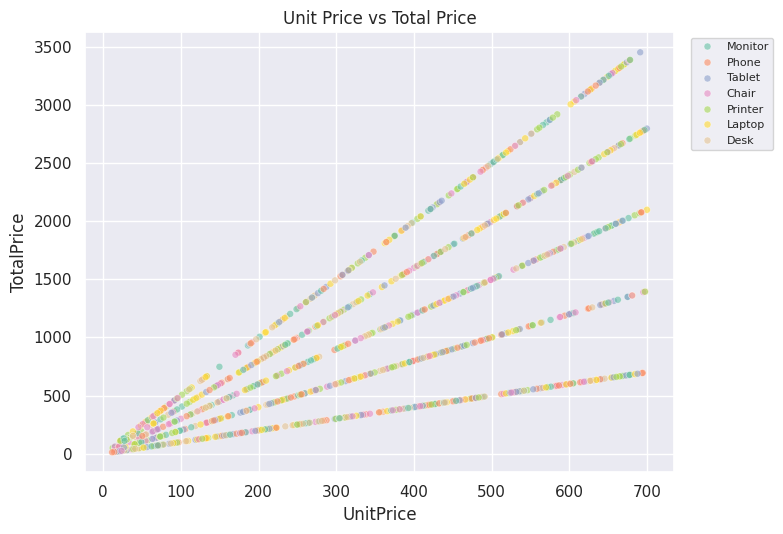

In [18]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df_clean, x="UnitPrice", y="TotalPrice", hue="Product", alpha=0.6, palette="Set2", s=25)
plt.title("Unit Price vs Total Price")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../visuals/10_unitprice_vs_totalprice.png", dpi=150)
plt.show()

## 12. A few numbers worth calling out

In [19]:
cancel_return_pct = (df_clean["OrderStatus"].isin(["Cancelled", "Returned"]).sum() / len(df_clean) * 100)
coupon_usage_pct = (df_clean["CouponCode"] != "NONE").mean() * 100

print(f"Cancelled + Returned share of all orders: {cancel_return_pct:.1f}%")
print(f"Orders that used a coupon code: {coupon_usage_pct:.1f}%")
print(f"Median order value: {df_clean['TotalPrice'].median():.2f}")
print(f"Mean order value: {df_clean['TotalPrice'].mean():.2f}")

Cancelled + Returned share of all orders: 41.4%
Orders that used a coupon code: 74.2%
Median order value: 823.62
Mean order value: 1053.97


## 13. Summary

- Data is clean - no duplicates, no calculation errors. The only "missing"
  column (CouponCode) isn't really missing data, it just means no coupon used.
- TotalPrice is right-skewed, so median (823.62) is more representative than
  mean (1053.97) when talking about a typical order.
- 8 outlier orders in TotalPrice - all large orders, kept as-is since they
  look genuine.
- Cancelled + Returned orders make up about 41% of everything - biggest thing
  worth looking into further.
- UnitPrice and TotalPrice are fairly correlated (0.72) as expected. UnitPrice
  and Quantity aren't correlated at all (0.01).

## 14. Things I'd look at next

- Why so many orders get cancelled/returned - could be payment method,
  product type, or something else
- Whether the different coupon codes are actually worth it (ROI per code)
- Grouping customers by order frequency and value
